In [1]:
import geopandas as gpd
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

In [15]:
districts = gpd.read_file(
    r"C:\Users\Vaishnavi\OneDrive\Desktop\Water Stress\district 2"
)

districts.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,IND.1.1_1,IND,India,IND.1_1,Andaman and Nicobar,NA,Nicobar Islands,NA,NA,District,District,NA,IN.AN.NI,"MULTIPOLYGON (((93.78988 6.85201, 93.79015 6.8..."
1,IND.1.2_1,IND,India,IND.1_1,Andaman and Nicobar,NA,North and Middle Andaman,NA,NA,District,District,NA,IN.AN.NM,"MULTIPOLYGON (((92.84441 12.14969, 92.84466 12..."
2,IND.1.3_1,IND,India,IND.1_1,Andaman and Nicobar,NA,South Andaman,NA,NA,District,District,NA,IN.AN.SA,"MULTIPOLYGON (((92.52111 10.89694, 92.52306 10..."
3,IND.2.1_1,IND,India,IND.2_1,Andhra Pradesh,NA,Anantapur,"Anantpur, Ananthapur",NA,District,District,NA,IN.AD.AN,"POLYGON ((77.846 13.92832, 77.83012 13.92715, ..."
4,IND.2.2_1,IND,India,IND.2_1,Andhra Pradesh,NA,Chittoor,Chitoor|Chittor,NA,District,District,NA,IN.AD.CH,"POLYGON ((78.54555 12.74391, 78.55031 12.73876..."


In [4]:
rivers = gpd.read_file(
    r"C:\Users\Vaishnavi\OneDrive\Desktop\Water Stress\HydroRIVERS_v10_as_shp"
)

rivers.head()

,HYRIV_ID,NEXT_DOWN,MAIN_RIV,LENGTH_KM,DIST_DN_KM,DIST_UP_KM,CATCH_SKM,UPLAND_SKM,ENDORHEIC,DIS_AV_CMS,ORD_STRA,ORD_CLAS,ORD_FLOW,HYBAS_L12,geometry
0,40000001,40000019,40017702,2.48,3056.6,6.9,14.93,14.9,0,0.133,1,5,7,4121166050,"LINESTRING (124.60417 55.87708, 124.61875 55.8..."
1,40000002,40000019,40017702,1.23,3056.8,6.0,12.76,12.8,0,0.120,1,6,7,4121166050,"LINESTRING (124.63542 55.88333, 124.63542 55.8..."
2,40000003,40000015,40017702,1.26,3052.8,7.4,11.80,11.8,0,0.100,1,7,7,4120080930,"LINESTRING (125.24583 55.85417, 125.23958 55.8..."
3,40000004,40000015,40017702,1.30,3052.6,7.9,2.17,24.9,0,0.195,2,6,7,4120080930,"LINESTRING (125.26042 55.84375, 125.23958 55.8..."
4,40000005,40000004,40017702,0.69,3054.1,6.4,10.84,10.8,0,0.090,1,7,8,4120080930,"LINESTRING (125.26042 55.85, 125.26042 55.84375)"


In [9]:
lakes = gpd.read_file(
    r"C:\Users\Vaishnavi\OneDrive\Desktop\Water Stress\HydroLAKES_polys_v10_shp"
)

lakes.head()

,Hylak_id,Lake_name,Country,Continent,Poly_src,Lake_type,Grand_id,Lake_area,Shore_len,Shore_dev,...,Vol_src,Depth_avg,Dis_avg,Res_time,Elevation,Slope_100,Wshd_area,Pour_long,Pour_lat,geometry
0,1,Caspian Sea,Russia,Europe,SWBD,1,0,377001.91,15829.37,7.27,...,1,200.5,8110.642,107883.0,-29,-1.0,1404108.0,47.717708,45.591934,"POLYGON ((49.96181 37.43847, 49.96457 37.44022..."
1,2,Great Bear,Canada,North America,CanVec,1,0,30450.64,5331.72,8.62,...,1,72.2,535.187,47577.7,145,-1.0,147665.4,-123.505546,65.138384,"POLYGON ((-119.78782 67.03574, -119.78637 67.0..."
2,3,Great Slave,Canada,North America,CanVec,1,0,26734.29,9814.16,16.93,...,1,59.1,4350.692,4203.2,148,-1.0,995312.3,-117.617115,61.311727,"POLYGON ((-109.93976 62.95851, -109.93831 62.9..."
3,4,Winnipeg,Canada,North America,CanVec,3,709,23923.04,4018.32,7.33,...,1,11.9,2244.727,1464.3,215,-1.0,919611.5,-97.863542,53.696359,"POLYGON ((-98.80636 53.88021, -98.80578 53.880..."
4,5,Superior,United States of America,North America,SWBD,1,0,81843.92,5248.36,5.18,...,1,146.7,2869.953,48410.3,179,-1.0,209219.5,-84.460547,46.468593,"POLYGON ((-90.7225 46.6574, -90.72458 46.65783..."


In [6]:
population = pd.read_csv(
    r"C:\Users\Vaishnavi\OneDrive\Desktop\Water Stress\India (1).csv"
)
population.head()   

,State,District,Latitude,Longitude,District code,Population,Sex_ratio,Literacy_rate,Male_Literacy_rate,Female_Literacy_rate,...,Power_Parity_Rs_45000_90000_ratio,Power_Parity_Rs_90000_150000_ratio,Power_Parity_Rs_45000_150000_ratio,Power_Parity_Rs_150000_240000_ratio,Power_Parity_Rs_240000_330000_ratio,Power_Parity_Rs_150000_330000_ratio,Power_Parity_Rs_330000_425000_ratio,Power_Parity_Rs_425000_545000_ratio,Power_Parity_Rs_330000_545000_ratio,Power_Parity_Above_Rs_545000_ratio
0,Andhra Pradesh,Adilabad,19.284514,78.813212,532,2741239,1001.0,54.0,63.0,46.0,...,38.0,30.0,69.0,2.0,3.0,5.0,3.0,5.0,8.0,3.0
1,Andhra Pradesh,Anantapur,14.312066,77.460158,553,4081148,977.0,57.0,65.0,48.0,...,39.0,28.0,67.0,2.0,3.0,5.0,3.0,5.0,8.0,4.0
2,Andhra Pradesh,Chittoor,13.331093,78.927639,554,4174064,997.0,64.0,71.0,57.0,...,38.0,26.0,65.0,4.0,2.0,7.0,3.0,4.0,6.0,5.0
3,Andhra Pradesh,East Godavari,16.782718,82.243207,545,5154296,1006.0,64.0,67.0,61.0,...,40.0,27.0,67.0,3.0,2.0,5.0,3.0,4.0,7.0,4.0
4,Andhra Pradesh,Guntur,15.884926,80.586576,548,4887813,1003.0,61.0,67.0,54.0,...,38.0,28.0,66.0,3.0,3.0,6.0,3.0,5.0,8.0,5.0


In [11]:
rain = rasterio.open(
    r"C:\Users\Vaishnavi\OneDrive\Desktop\Water Stress\rainfall\wc2.1_cruts4.09_2.5m_prec_2020-01.tif"
)

print(rain.meta)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 8640, 'height': 4320, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.041666666666666664, 0.0, -180.0,
       0.0, -0.041666666666666664, 90.0)}


In [19]:
# Converting the coordinates to crs 

districts = districts.to_crs(3857)
lakes = lakes.to_crs(3857)
rivers = rivers.to_crs(3857)

In [13]:
# checking 
print(districts.crs)
print(rivers.crs)
print(lakes.crs)

EPSG:3857
EPSG:3857
EPSG:3857


In [23]:
# merging the population csv file

districts = districts.merge(
    population,
    left_on="NAME_2",
    right_on="District",
    how="left"
)
districts

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,...,Power_Parity_Rs_45000_90000_ratio,Power_Parity_Rs_90000_150000_ratio,Power_Parity_Rs_45000_150000_ratio,Power_Parity_Rs_150000_240000_ratio,Power_Parity_Rs_240000_330000_ratio,Power_Parity_Rs_150000_330000_ratio,Power_Parity_Rs_330000_425000_ratio,Power_Parity_Rs_425000_545000_ratio,Power_Parity_Rs_330000_545000_ratio,Power_Parity_Above_Rs_545000_ratio
0,IND.1.1_1,IND,India,IND.1_1,Andaman and Nicobar,NA,Nicobar Islands,NA,NA,District,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IND.1.2_1,IND,India,IND.1_1,Andaman and Nicobar,NA,North and Middle Andaman,NA,NA,District,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IND.1.3_1,IND,India,IND.1_1,Andaman and Nicobar,NA,South Andaman,NA,NA,District,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IND.2.1_1,IND,India,IND.2_1,Andhra Pradesh,NA,Anantapur,"Anantpur, Ananthapur",NA,District,...,39.0,28.0,67.0,2.0,3.0,5.0,3.0,5.0,8.0,4.0
4,IND.2.2_1,IND,India,IND.2_1,Andhra Pradesh,NA,Chittoor,Chitoor|Chittor,NA,District,...,38.0,26.0,65.0,4.0,2.0,7.0,3.0,4.0,6.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1210,IND.36.16_1,IND,India,IND.36_1,West Bengal,NA,Pashchim Medinipur,Paschim Medinipur,NA,District,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1211,IND.36.17_1,IND,India,IND.36_1,West Bengal,NA,Purba Medinipur,Purba Medinipur,NA,District,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1212,IND.36.18_1,IND,India,IND.36_1,West Bengal,NA,Puruliya,NA,NA,District,...,40.0,20.0,61.0,9.0,3.0,12.0,2.0,4.0,6.0,2.0
1213,IND.36.19_1,IND,India,IND.36_1,West Bengal,NA,South 24 Parganas,NA,NA,District,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
districts["Area_sqkm"] = districts.area / 1e6

In [29]:
# population Density

districts["Pop_Density"] = (
    districts["Population"] /
    districts["Area_sqkm"]
)

In [30]:
# River Count to estimate water availability

river_join = gpd.sjoin(
    districts,
    rivers,
    predicate="intersects"
)

river_count = river_join.groupby(
    "NAME_2"
).size()

districts["River_Count"] = (
    districts["NAME_2"]
    .map(river_count)
    .fillna(0)
)

In [31]:
# Lake Count

lake_join = gpd.sjoin(
    districts,
    lakes,
    predicate="intersects"
)

lake_count = lake_join.groupby(
    "NAME_2"
).size()

districts["Lake_Count"] = (
    districts["NAME_2"]
    .map(lake_count)
    .fillna(0)
)

In [40]:
# distance of river from land

river_union = rivers.unary_union

districts["River_Distance"] = (
    districts.centroid.distance(
        river_union
    ) / 1000
)

C:\Users\Vaishnavi\AppData\Local\Temp\ipykernel_8540\4028140426.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  river_union = rivers.unary_union


In [44]:
# Calculating mean rainfall

from rasterstats import zonal_stats

districts_rain = districts.to_crs(4326)
stats = zonal_stats(
    districts_rain ,
    r"C:\Users\Vaishnavi\OneDrive\Desktop\Water Stress\rainfall\wc2.1_cruts4.09_2.5m_prec_2020-01.tif",
    stats="mean"
)

districts["Rainfall"] = [
    s["mean"] for s in stats
]

In [45]:
# NOrmalizing the vairables by using MinMaxScaler library of sikit learn

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

districts_rain["Rainfall_N"] = scaler.fit_transform(
    districts[["Rainfall"]]
)

districts_rain["Population_N"] = scaler.fit_transform(
    districts[["Pop_Density"]]
)

districts_rain["River_N"] = scaler.fit_transform(
    districts[["River_Distance"]]
)

districts_rain["Lake_N"] = scaler.fit_transform(
    districts[["Lake_Count"]]
)

In [46]:
# Calculating water stress index

districts_rain["Water_Stress"] = (
    0.40 * (1 - districts_rain["Rainfall_N"]) +
    0.30 * districts_rain["Population_N"] +
    0.20 * districts_rain["River_N"] +
    0.10 * (1 - districts_rain["Lake_N"])
)

In [49]:
#40% Rainfall :- Less rainfall increases stress.
#30% Population Density :- More people increase demand.
#20% River Distance :- Districts farther from rivers may have reduced surface water access.
#10% Lake Density :- More lakes generally reduce stress.

districts_rain[["NAME_1", "NAME_2", "Water_Stress"]]

,NAME_1,NAME_2,Water_Stress
0,Andaman and Nicobar,Nicobar Islands,NaN
1,Andaman and Nicobar,North and Middle Andaman,NaN
2,Andaman and Nicobar,South Andaman,NaN
3,Andhra Pradesh,Anantapur,0.499346
4,Andhra Pradesh,Chittoor,0.489426
...,...,...,...
1210,West Bengal,Pashchim Medinipur,NaN
1211,West Bengal,Purba Medinipur,NaN
1212,West Bengal,Puruliya,0.470603
1213,West Bengal,South 24 Parganas,NaN


In [50]:
# Classifying the index

districts_rain["Risk"] = pd.cut(
    districts_rain["Water_Stress"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

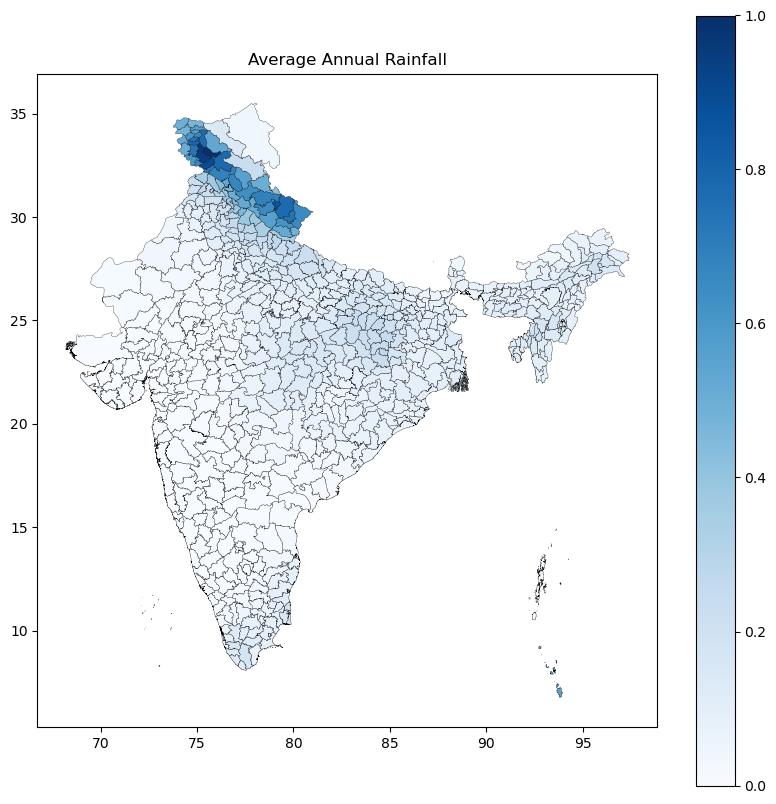

In [53]:
# Rainfall Map

fig, ax = plt.subplots(figsize=(10, 10))

districts_rain.plot(
    column="Rainfall_N",
    cmap="Blues",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.2
)

ax.set_title("Average Annual Rainfall")
plt.show()

C:\Users\Vaishnavi\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


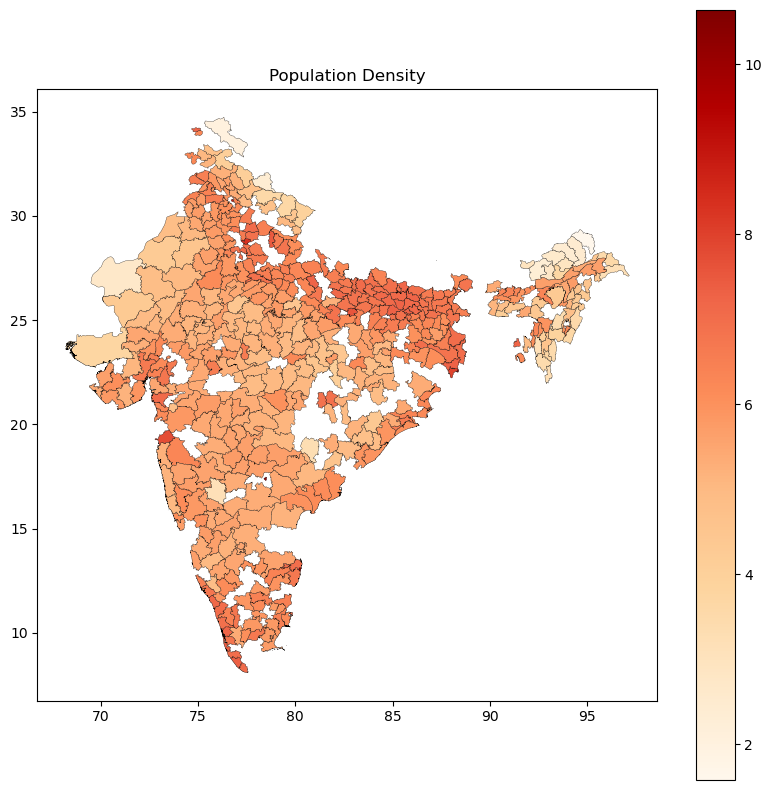

In [75]:
# Population Density

import numpy as np

districts_rain["Log_Pop_Density"] = np.log1p(districts_rain["Pop_Density"])


fig, ax = plt.subplots(figsize=(10, 10))

districts_rain.plot(
    column="Log_Pop_Density",
    cmap="OrRd",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.2
)

ax.set_title("Population Density")
plt.show()

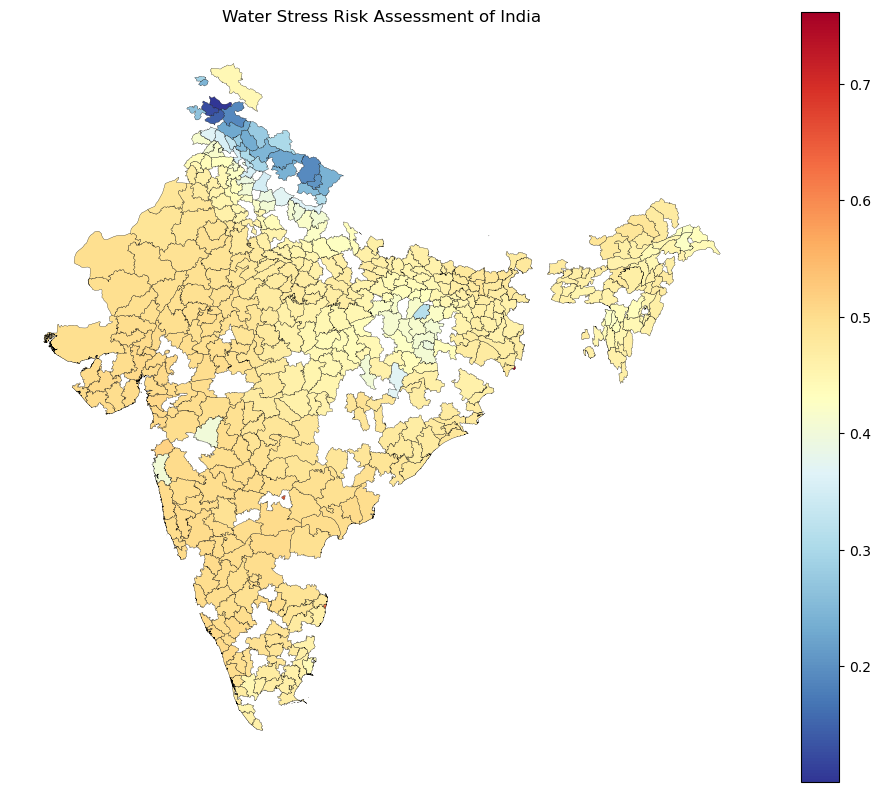

In [79]:
# Water stress 

fig, ax = plt.subplots(figsize=(12, 10))

districts_rain.plot(
    column='Water_Stress',
    cmap="RdYlBu_r",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.2
)

ax.set_title("Water Stress Risk Assessment of India")
plt.axis("off")
plt.show()

In [80]:
# TOP 20 Districts with water stress

top20 = districts_rain.nlargest(20, "Water_Stress")

top20[
    [
        "NAME_1",
        "NAME_2",
        "Water_Stress"
    ]
]

,NAME_1,NAME_2,Water_Stress
1205,West Bengal,Kolkata,0.761798
1017,Telangana,Hyderabad,0.642833
985,Tamil Nadu,Chennai,0.623692
328,Daman and Diu,Daman,0.520084
841,Maharashtra,Thane,0.515261
366,Gujarat,Surat,0.508322
370,Gujarat,Vadodara,0.506105
624,Kerala,Kozhikode,0.505966
361,Gujarat,Panch Mahals,0.505090
332,Gujarat,Ahmadabad,0.504960


In [82]:
# Exporting the output in a csv file 

districts_rain.to_file(
    r"C:\Users\Vaishnavi\OneDrive\Desktop\Water Stress\final.geojson",
    driver="GeoJSON"
)

top20.to_csv(
    r"C:\Users\Vaishnavi\OneDrive\Desktop\Water Stress\top20_water_stress.csv",
    index=False
)